In [211]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [3]:
def f(x):
  return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

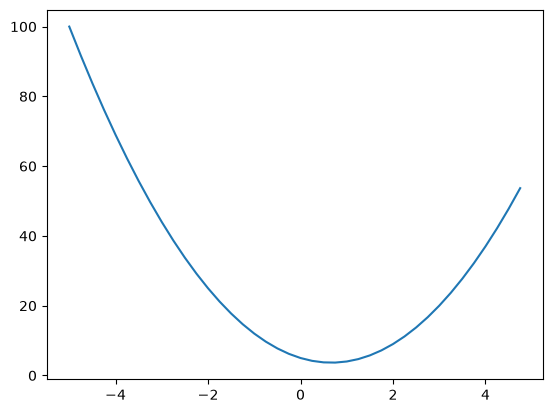

In [7]:
xs = np.arange(-5, 5, 0.25) # -5 to 5 in 0.25 increments
ys = f(xs)
ys
plt.plot(xs, ys)

In [22]:
h = 0.00000000000001
x = -3.0
(f(x+h) - f(x))/h ## slope, i.e. how much does y change when we increase x slightly


-22.737367544323206

In [37]:
# more complex case to understand 

h = 0.0001

# inputs:
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

b += h
d2 = a * b + c

print ({d1, d2, (d2-d1)/h})


{2.0000000000042206, 4.0, 4.0002}


In [38]:
# Value object does the hard work

In [179]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0 # derivative of the output wrt this variable
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # to support non Value operations
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad # Important: We do +=, not = because a node can be used multiple times
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __radd__(self, other): # other + self
        return self + other        

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # to support non Value operations
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
    
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
    
        return out

    # can't do tanh with add, mul alone
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
          self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self): # e^self
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
          self.grad += out.data * out.grad # out.data is the derivative here: d/dx(e^x) = e^x
        out._backward = _backward
        
        return out
  

    def backward(self):
        self.grad = 1
        sorted = [] # input to output
        visited = set()
        def build_sorted(n):
            if n in visited: return;
            visited.add(n)
            for child in n._prev:
                build_sorted(child)
            sorted.append(n)
        build_sorted(self)
        for node in reversed(sorted):
          node._backward()
                
                
        



a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L # loss fn

Value(data=-8.0)

In [180]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

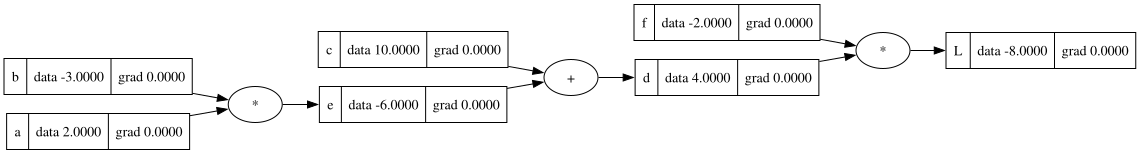

In [181]:
draw_dot(L)

In [200]:
'''
L = loss fn
we want to compute derivative of L wrt the weights
the weights are some leaf nodes (other leaf nodes are data and data is fixed)

at each step we calculate derivative of L wrt this Value and store it in `self.grad`


step 0:
dL/dL = 1 so we set L.grad = 1

step 1:
remember, L = d*f
dL/dd = f (simple math)
and dL/df = d

so we set f.grad = d.data and d.grad = f.data

step 3:
remember, d = c + e
for dL/dc, we know dd/dc = 1 and dd/de = 1 (math again)
using chain rule (dz/dx = dz/dy * dy/dx),
dL/dc = dL/dd * dd/dc
so, c.grad = d.grad * 1 (dd/dc)
similarly, e.grad

can think of it like: "+" nodes just route the derivative of the other nodes down

continue recursively until at head of chain
'''


'\nL = loss fn\nwe want to compute derivative of L wrt the weights\nthe weights are some leaf nodes (other leaf nodes are data and data is fixed)\n\nat each step we calculate derivative of L wrt this Value and store it in `self.grad`\n\n\nstep 0:\ndL/dL = 1 so we set L.grad = 1\n\nstep 1:\nremember, L = d*f\ndL/dd = f (simple math)\nand dL/df = d\n\nso we set f.grad = d.data and d.grad = f.data\n\nstep 3:\nremember, d = c + e\nfor dL/dc, we know dd/dc = 1 and dd/de = 1 (math again)\nusing chain rule (dz/dx = dz/dy * dy/dx),\ndL/dc = dL/dd * dd/dc\nso, c.grad = d.grad * 1 (dd/dc)\nsimilarly, e.grad\n\ncan think of it like: "+" nodes just route the derivative of the other nodes down\n\ncontinue recursively until at head of chain\n'

In [201]:
'''
neural network neuron 
https://www.cs.toronto.edu/~lczhang/360/lec/w02/terms.html
'''

'\nneural network neuron \nhttps://www.cs.toronto.edu/~lczhang/360/lec/w02/terms.html\n'

In [202]:
# Single neuron
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [203]:
o

Value(data=0.7071067811865476)

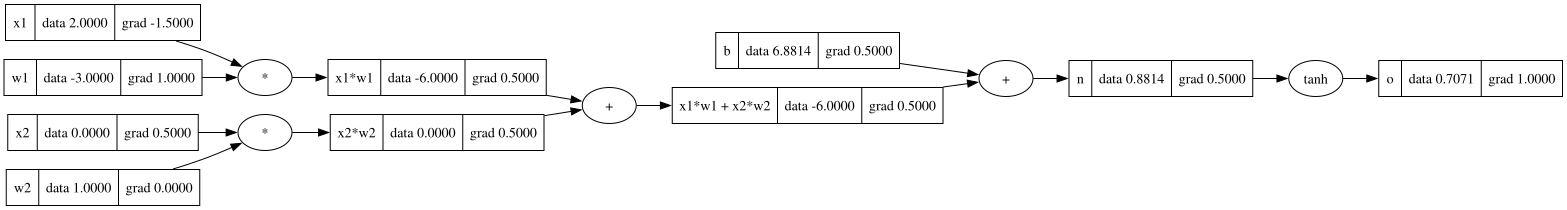

In [204]:
o.backward()
draw_dot(o)

In [205]:
import torch

In [206]:
# Equivalent code in pytorch! Grad values below are roughly the same
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [292]:
# Building a Neuron, MLP similar to Torch API

'''
example: neuron firing on input x
x = [2.0, 3.0, -1.0]
n = Neuron(3) #input_count = len(x)
n(x)
'''
class Neuron:
    def __init__(self, input_count):
        self.w = [Value(random.uniform(-1,1)) for _ in range(input_count)] # weights
        self.b = Value(random.uniform(-1,1)) # bias

    # Support calling the neuron on an array of inputs (x)    
    def __call__(self, x):
        # w * x + b
        s = sum([wi * xi for wi, xi in zip(self.w, x)]) # sum(wi * xi)
        act = s + self.b
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b] # all weights + bias 

'''
example:
x = [2.0, 3.0, -1.0]
n = Layer(3, 4) # nin = len(x)
n(x)
'''
class Layer:
    '''
    each layer has `nin` inputs
    each neuron has one output so we need `nout` neurons total
    see diagram in link above
    '''
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] 

    # Run the layer on inputs (x), producing outputs
    def __call__(self, x):
        # each neuron acts on the entire input x and produces one output
        return [ni(x) for ni in self.neurons]

    def parameters(self):
        p = []
        for n in self.neurons:
            p.extend(n.parameters())
        return p


'''
Multi-layer perceptron
example:
x = [2.0, 3.0, -1.0]
n = MLP(3, 2)
n(x)
'''
class MLP:
    # nouts = size of each layer in MLP
    def __init__(self, nin, nouts):
      sizes = [nin] + nouts # list of all layer sizes
      self.layers = [ Layer(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)  ]

    def __call__(self, x):
        o = x
        for l in self.layers:
            o = l(o) # call each layer one at a time
        return o

    def parameters(self):
        p = []
        for l in self.layers:
            p.extend(l.parameters())
        return p

In [293]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

[Value(data=0.5700046018841407)]

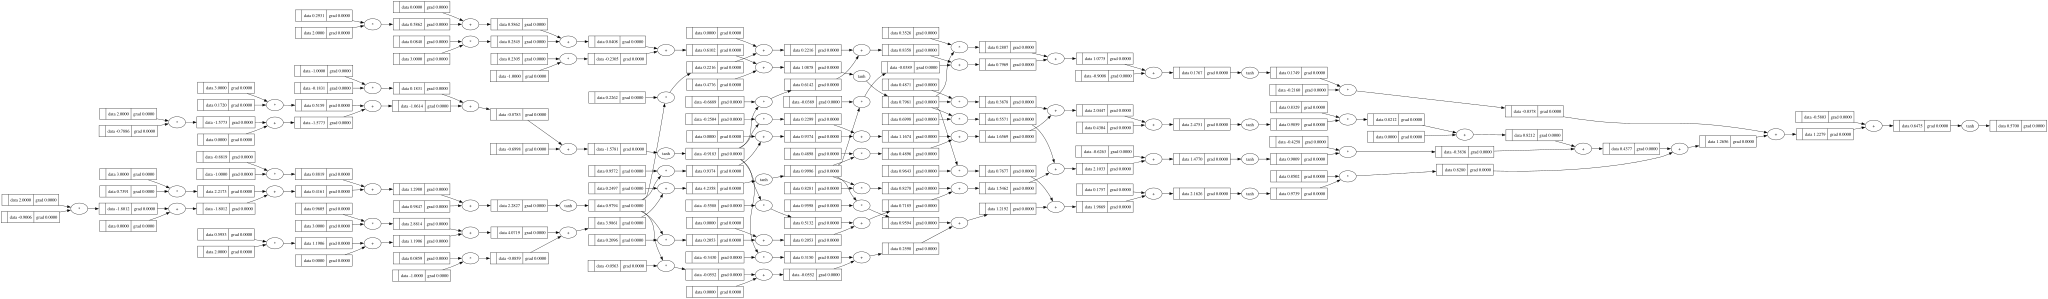

In [294]:
# karpathy has a convenience where Layer.__call__ returns the 0th element of a single list that I've omitted here so we need to do [0]
draw_dot(n(x)[0])

In [466]:
# Simple example with 4 data points
# Binary classifier - output is -1 or 1
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

n = MLP(3, [4, 4, 1])
ypred = [n(x) for x in xs]
ypred

[[Value(data=-0.8536156154668917)],
 [Value(data=-0.8553574245113733)],
 [Value(data=-0.7358529528220507)],
 [Value(data=-0.28249468857903637)]]

In [403]:
'''
need to calculate `loss` that measures the performance of the NN
'''

'\nneed to calculate `loss` that measures the performance of the NN\n'

In [404]:
loss = sum((yout[0] - ya)**2 for yout, ya in zip(ypred, ys))
loss

Value(data=6.5476673646050205)

In [405]:
loss.backward()

In [406]:
n.layers[0].neurons[0].w[0].grad

0.3746344697042693

In [407]:
# draw_dot(loss)

In [408]:
len(n.parameters())

41

In [411]:
h = 0.01
for p in n.parameters():
    p.data += -h * p.grad
# observe that the data changes
n.layers[0].neurons[0].w[0].data

-0.9076061495107284

In [531]:
# simple training loop
h = 0.1 
for _ in range(100):

    # 1/ fwd pass
    ypred = [n(x) for x in xs]
    loss = sum((yout[0] - ya)**2 for yout, ya in zip(ypred, ys))

    # 2/ backward pass
    for p in n.parameters(): # need to zero out grad first so the grad isn't polluted by old backwards pass
      p.grad = 0
    loss.backward()

    print(loss)
    
    # 3/ Update data
    # TODO: learning rate decay (learning rate becomes smaller as we train more)
    for p in n.parameters():
      p.data += -h * p.grad

print(loss)    


Value(data=0.0002656985205242605)
Value(data=0.0002653101553058534)
Value(data=0.0002649229124994967)
Value(data=0.00026453678726394)
Value(data=0.0002641517747856726)
Value(data=0.00026376787027875963)
Value(data=0.00026338506898459363)
Value(data=0.00026300336617174987)
Value(data=0.00026262275713574473)
Value(data=0.0002622432371988932)
Value(data=0.00026186480171006904)
Value(data=0.00026148744604456947)
Value(data=0.00026111116560387514)
Value(data=0.0002607359558155049)
Value(data=0.0002603618121328171)
Value(data=0.00025998873003482416)
Value(data=0.0002596167050260195)
Value(data=0.00025924573263618703)
Value(data=0.0002588758084202407)
Value(data=0.0002585069279580393)
Value(data=0.00025813908685420666)
Value(data=0.0002577722807379677)
Value(data=0.00025740650526297453)
Value(data=0.00025704175610713123)
Value(data=0.0002566780289724295)
Value(data=0.0002563153195847843)
Value(data=0.0002559536236938557)
Value(data=0.0002555929370729123)
Value(data=0.0002552332555186157)
Valu

In [532]:
ypred # nearly matches ys (desired output) after running training a bunch

[[Value(data=0.9923485872056214)],
 [Value(data=-0.9960334488196974)],
 [Value(data=-0.9904536943698458)],
 [Value(data=0.9918380029730446)]]